# Import libraries

In [1]:
import pandas as pd
import geonamescache
import re
import nltk
import folium
from folium.plugins import HeatMap
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Get list of cities' names

In [2]:
gc = geonamescache.GeonamesCache()
cities = gc.get_cities()
city_names = set(city['name'] for city in cities.values()) # use set to avoid duplicate items

print(f"Total cities: {len(city_names)}")
print(list(city_names)[:10])

Total cities: 30699
['Tarko-Sale', 'Short Pump', 'Shīshgarh', 'Ōiso', 'Southbridge', 'Sumberpucung', 'Brandýs nad Labem-Stará Boleslav', 'Araure', 'Miyakonojō', 'Kabare']


Read data from hugging face

In [3]:
df = pd.read_csv("hf://datasets/maharshipandya/spotify-tracks-dataset/dataset.csv")

c:\Users\Pitchaporn\OneDrive\Documents\side projects\song and city\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [5]:
nltk.download('words', quiet=True)
nltk.download('names', quiet=True)
from nltk.corpus import words, names

# Get common English words and names
english_words = set(w.lower() for w in words.words())
common_names = set(n.lower() for n in names.words())

# Build city list that we will use to match against song titles
filtered_cities = []
for city in cities.values():
    name = city['name']
    lower = name.lower()
    # Select only big cities with population >= 500,000
    if city['population'] < 500000:
        continue
    # Skip if it's a common English word
    if lower in english_words:
        continue
    # Skip if it's a common first name
    if lower in common_names:
        continue
    
    filtered_cities.append(name)

filtered_cities.remove("Queens") # Manually remove "Queens" since it more refers to queen as noun

filtered_cities = list(set(filtered_cities))
print(f"Cities after filtering: {len(filtered_cities)}")

Cities after filtering: 1011


# Build regex pattern to match cities in th song title
1. .escape() is for escape special regex characters in each city name
2. Sort city name by length

In [6]:
# Abbreviation of US cities (except New York which is state)
us_abbreviations = {
    'NYC': 'New York',
    'LA': 'Los Angeles',
    'SF': 'San Francisco',
    'NOLA': 'New Orleans',
    'DC': 'Washington',
    'ATL': 'Atlanta',
    'Vegas': 'Las Vegas'
}

In [7]:
# Build regex pattern to match city names in song titles
# Longest one will be matched first to avoid partial matches (e.g. "York" in "New York")
city_pattern = r'\b(' + '|'.join(re.escape(city) for city in sorted(filtered_cities, key=len, reverse=True)) + r')\b'

# Pattern for abbreviations (case-sensitive)
abbrev_pattern = r'\b(' + '|'.join(re.escape(k) for k in sorted(us_abbreviations.keys(), key=len, reverse=True)) + r')\b'

df['track_name'] = df['track_name'].fillna('')
clean_titles = (df['track_name']
    .str.split('-').str[0]        
    .str.replace(r'\(.*?\)', '', regex=True)  # remove (...)
    .str.replace(r'\[.*?\]', '', regex=True)  # remove [...]
    .str.strip()
)

# Match cities (case-insensitive)
city_matches = clean_titles.str.extract(city_pattern, flags=re.IGNORECASE)

# Match abbreviations (case-sensitive)
abbrev_matches = clean_titles.str.extract(abbrev_pattern)

# Combine results
city_mask = city_matches[0].notna()
abbrev_mask = abbrev_matches[0].notna()

matched_songs = df[city_mask | abbrev_mask].copy()
matched_songs['matched_city'] = city_matches[0][city_mask | abbrev_mask].str.title()

# Fill in abbreviation matches and remap to full city names
abbrev_filled = abbrev_matches[0][city_mask | abbrev_mask]
matched_songs.loc[abbrev_mask, 'matched_city'] = abbrev_filled[abbrev_mask].map(us_abbreviations)

print(f"Found {len(matched_songs)} songs with city names")
matched_songs[['track_name', 'matched_city']]

Found 394 songs with city names


,track_name,matched_city
189,"Portland, Maine",Portland
1095,Bogotá - Live,Bogotá
1525,Bogotá (Instrumental),Bogotá
1901,Lagos Sisi,Lagos
3628,Brooklyn Zoo,Brooklyn
...,...,...
112143,Ankara,Ankara
112234,Rapsodi İstanbul,İstanbul
112350,My Name Is Tokyo,Tokyo
112419,İZMİR CONFIDENTIAL,İzmi̇r


In [8]:
# Drop duplicates case-insensitive
matched_songs['_track_lower'] = matched_songs['track_name'].str.lower()
matched_songs['_city_lower'] = matched_songs['matched_city'].str.lower()
matched_songs = matched_songs.drop_duplicates(subset=['_track_lower', '_city_lower'])
matched_songs = matched_songs.drop(columns=['_track_lower', '_city_lower'])

# Drop LA with latin category
matched_songs = matched_songs[~((matched_songs['matched_city'] == 'Los Angeles') & ((matched_songs['track_genre'] == 'latin')|(matched_songs['track_genre'] == 'spanish')|(matched_songs['track_genre'] == 'latino')|(matched_songs['track_genre']=='french')))]
matched_songs = matched_songs[matched_songs['track_genre'] != 'comedy']
# Check for duplicates in matched songs
print(f"Total matched songs: {len(matched_songs)}")
print(f"Unique matched cities: {matched_songs['matched_city'].nunique()}")
print()

# Show city frequency
city_counts = matched_songs['matched_city'].value_counts()
# Only select cities with more than 2 songs
city_counts = city_counts[city_counts > 2]
print("Top 10 cities by song count:")
print(city_counts.head(10))
print()

Total matched songs: 231
Unique matched cities: 84

Top 10 cities by song count:
matched_city
London          33
Tokyo           17
Buenos Aires    16
Brooklyn         7
Los Angeles      7
Amsterdam        6
Chicago          5
Cali             5
Malang           5
Kyoto            4
Name: count, dtype: int64



In [9]:
# Convert Series to DataFrame
city_counts_df = city_counts.reset_index()
city_counts_df.columns = ['city', 'song_count']

# Add coordinates from geonamescache
city_coords = {}
for city in cities.values():
    name = city['name'].title()
    if name == 'Istanbul':  
        name = 'İstanbul'  # Use the correct Turkish spelling
        city_coords[name] = {
            'lat': city['latitude'],
            'lon': city['longitude'],
            'population': city['population'],
            'country': city['countrycode']
        }
    if name not in city_coords or city['population'] > city_coords[name]['population']:
        city_coords[name] = {
            'lat': city['latitude'],
            'lon': city['longitude'],
            'population': city['population'],
            'country': city['countrycode']
        }

city_counts_df['lat'] = city_counts_df['city'].map(lambda c: city_coords.get(c, {}).get('lat'))
city_counts_df['lon'] = city_counts_df['city'].map(lambda c: city_coords.get(c, {}).get('lon'))
city_counts_df['country'] = city_counts_df['city'].map(lambda c: city_coords.get(c, {}).get('country'))
city_counts_df = city_counts_df.dropna(subset=['lat', 'lon'])

In [10]:
m2 = folium.Map(location=[20, 0], zoom_start=2, tiles='CartoDB dark_matter')

heat_data = []
for _, row in city_counts_df.iterrows():
    heat_data.append([row['lat'], row['lon'], row['song_count']])

HeatMap(heat_data, radius=25, blur=15, max_zoom=5).add_to(m2)
m2.save('city_song_heatmap.html')
m2

In [11]:
# city_counts_df

{'London': 'GB', 'Tokyo': 'JP', 'Buenos Aires': 'AR', 'Brooklyn': 'US', 'Los Angeles': 'US', 'Amsterdam': 'NL', 'Chicago': 'US', 'Cali': 'CO', 'Malang': 'ID', 'Kyoto': 'JP', 'Detroit': 'US', 'Las Vegas': 'US', 'Fortaleza': 'BR', 'İstanbul': 'TR', 'Bogotá': 'CO', 'Denver': 'US', 'Memphis': 'US', 'Mumbai': 'IN', 'San Francisco': 'US', 'Göteborg': 'SE', 'Rotterdam': 'NL', 'La Paz': 'BO', 'Tehran': 'IR', 'Ankara': 'TR', 'Yokohama': 'JP'}


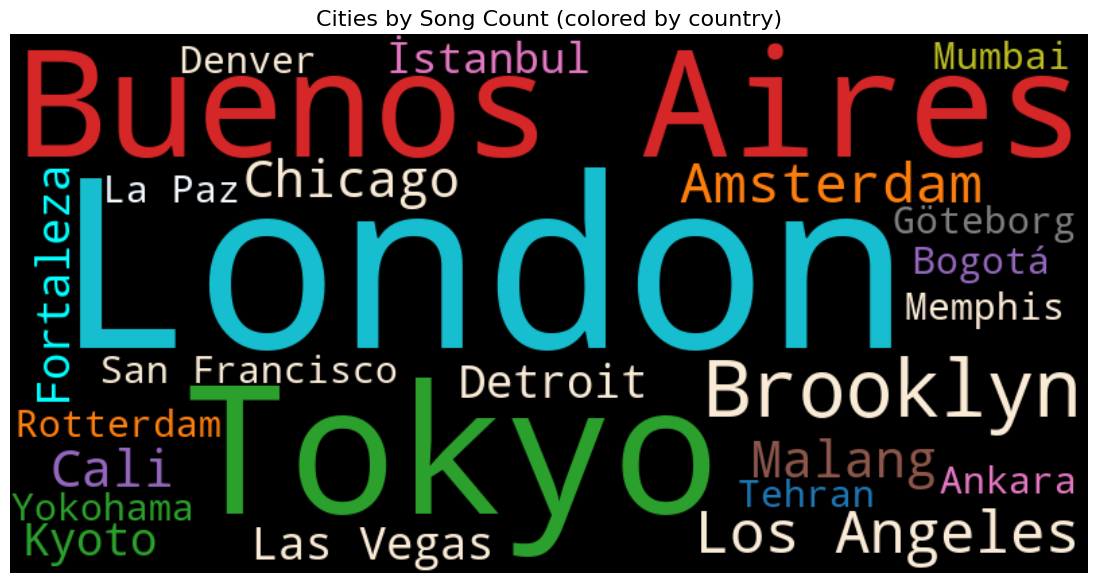

In [12]:
# map cities to country for wordcloud viz
unique_countries = list(set(city_counts_df['country']))
# Use a larger color palette to avoid duplicates colors
color_palette = (
    list(mcolors.TABLEAU_COLORS.values()) +   # 10 colors
    list(mcolors.CSS4_COLORS.values())         # 148 more colors
)
country_color_map = {country: color_palette[i] for i, country in enumerate(unique_countries)}

# Build a simple dict to map city name and country code
city_to_country = dict(zip(city_counts_df['city'], city_counts_df['country']))
print(city_to_country)

# Custom color function for word cloud
def color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    country = city_to_country.get(word, None)  # look up country by city name
    return country_color_map.get(country, '#FFFFFF')  # return color by country

# Generate word cloud
wc = WordCloud(width=800, height=400, background_color='black')
wc.generate_from_frequencies(city_counts)
wc.recolor(color_func=color_func)

plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Cities by Song Count (colored by country)', fontsize=16)

plt.show()

In [13]:
city_counts.head(5)

matched_city
London          33
Tokyo           17
Buenos Aires    16
Brooklyn         7
Los Angeles      7
Name: count, dtype: int64

# Remove duplicate songs
- London
    - track id: 3VuC6fpot8GhWsVdhXgazv, song: London Scammer - Remastered
    - track id: 1t3DFrE9ge66pbbFRcTSb4, song: The London Sketchbook, K. 15a-ss (arr. and/or ...	
    - track id: 2WnrNA0YgU06xhMcvjlaxD
    - track id: 7eLOzWaZQ6nwC0hzkyAecf
    - track id: 5gYCs6kj9HSy0kvo6EX2yU
    - track id: 0nU0O7aPqJaYW9F02b2N5y
    - track id: 17uvqOidaNSHxbH4FDuN8J
    - track id: 4VJPty61CscijK3fV5dIev
- Bueno Aires
    - 1p2FEZrj1dYiZW0ULirB46
    - 2fhTokoH0QZHlzwsrkdAz6
    - 0puvfam7d9rvSXWOoh1PGk
- LA
    - 6mIjJONoUMvGPT9Kzrab3L

In [14]:
matched_songs = matched_songs[~((matched_songs['track_id']=='3VuC6fpot8GhWsVdhXgazv') | 
                                (matched_songs['track_id']=='1t3DFrE9ge66pbbFRcTSb4') |
                                (matched_songs['track_id']=='2WnrNA0YgU06xhMcvjlaxD') |
                                (matched_songs['track_id']=='7eLOzWaZQ6nwC0hzkyAecf') |
                                (matched_songs['track_id']=='5gYCs6kj9HSy0kvo6EX2yU') |
                                (matched_songs['track_id']=='0nU0O7aPqJaYW9F02b2N5y') |
                                (matched_songs['track_id']=='17uvqOidaNSHxbH4FDuN8J') |
                                (matched_songs['track_id']=='4VJPty61CscijK3fV5dIev') |
                                (matched_songs['track_id']=='1p2FEZrj1dYiZW0ULirB46') |
                                (matched_songs['track_id']=='2fhTokoH0QZHlzwsrkdAz6') |
                                (matched_songs['track_id']=='6mIjJONoUMvGPT9Kzrab3L') |
                                (matched_songs['track_id']=='0puvfam7d9rvSXWOoh1PGk') |
                                (matched_songs['track_id']=='5dH9s6Wg3DvPmooGze7QVY') |
                                (matched_songs['track_id']=='4LgWrfYiwdstak9a4i6DZw') |
                                (matched_songs['track_id']=='6qNY8xr8GNcvskh5GkVS7b') |
                                (matched_songs['track_id']=='2U0BLmYoSESYOdwMxW2yA9') |
                                (matched_songs['track_id']=='4xmkpE1Si5JL7NFxWrhV0S') |
                                (matched_songs['track_id']=='4FWV2FO6fFRhSyAvbHoEcj'))]

In [15]:
matched_songs = matched_songs.drop(columns=['Unnamed: 0'])

# London

- kid and children -> 3 (after drop duplicate)
- classical -> 1
- chill -> 2

In [16]:
matched_songs[matched_songs['matched_city'] == 'London'].groupby('track_genre').size().sort_values(ascending=False)

track_genre
british          3
breakbeat        2
chicago-house    2
chill            2
children         2
alternative      1
classical        1
club             1
dancehall        1
deep-house       1
folk             1
grunge           1
happy            1
j-rock           1
kids             1
latin            1
opera            1
punk-rock        1
techno           1
dtype: int64

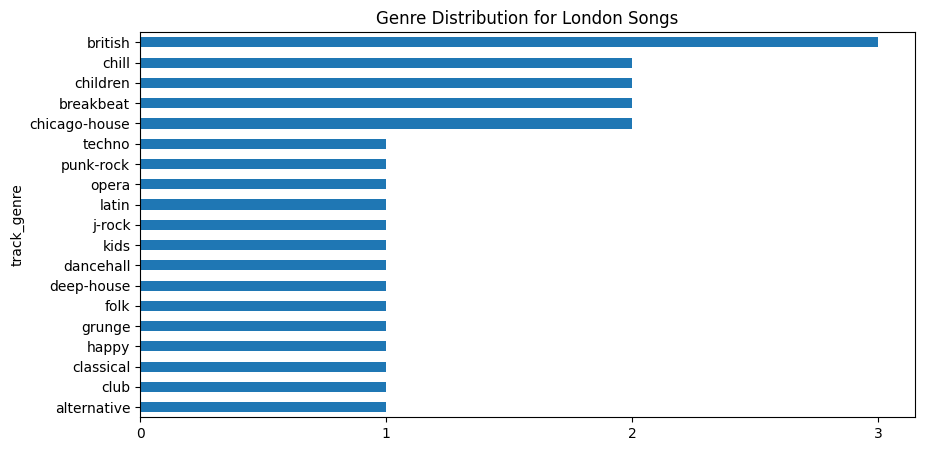

In [17]:
ax = matched_songs[matched_songs['matched_city'] == 'London'].groupby('track_genre').size().sort_values(ascending=True).plot(kind='barh', figsize=(10, 5), title='Genre Distribution for London Songs')
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.show()

In [18]:
matched_songs[(matched_songs['matched_city'] == 'London')][['artists', 'album_name', 'track_name', 'track_genre', 'popularity']]

,artists,album_name,track_name,track_genre,popularity
3880,Holly Humberstone,HÖST,London Is Lonely,alternative,1
10232,Freestylers,Pressure Point,London Sound,breakbeat,16
10716,Aphrodite,Aphro Classics 4,London Massive,breakbeat,12
11371,Lorne Balfe,Pennyworth: The Origin of Batman's Butler - Se...,Lullaby for London,british,8
11616,Harry Gregson-Williams,"The Chronicles of Narnia: The Lion, The Witch ...",Evacuating London,british,48
11632,Ralph McTell,Spiral Staircase (Expanded Edition),Streets of London,british,19
13079,Mr. Lee,Pump up Chicago,Pump up London,chicago-house,16
13815,Mr. Lee,The Acid Fantaslee,Acid Pump Up London,chicago-house,6
14063,CoComelon,Nursery Rhymes by CoComelon,London Bridge Is Falling Down,children,46
14345,Kidz Bop Kids,KIDZ BOP Halloween,Werewolves Of London,children,37


In [19]:
matched_songs[(matched_songs['matched_city'] == 'London')].describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.0,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.00
mean,34.160000,226872.360000,0.591480,0.600040,6.320000,-9.985960,0.6,0.084240,0.338399,0.267465,0.194564,0.482868,129.649480,3.96
std,23.501206,108559.991414,0.202713,0.275884,3.363034,6.172657,0.5,0.092658,0.357267,0.390738,0.217258,0.293825,25.294574,0.20
min,0.000000,47000.000000,0.136000,0.042000,0.000000,-29.017000,0.0,0.026700,0.000010,0.000000,0.055100,0.034200,81.195000,3.00
25%,16.000000,160225.000000,0.482000,0.430000,4.000000,-13.564000,0.0,0.035000,0.023100,0.000004,0.088900,0.187000,119.901000,4.00
50%,28.000000,204533.000000,0.632000,0.671000,6.000000,-8.290000,1.0,0.048100,0.123000,0.000626,0.114000,0.493000,132.001000,4.00
75%,54.000000,250722.000000,0.748000,0.807000,10.000000,-5.348000,1.0,0.066100,0.625000,0.709000,0.139000,0.678000,147.425000,4.00
max,72.000000,515159.000000,0.922000,0.999000,11.000000,-3.322000,1.0,0.328000,0.976000,0.968000,0.977000,0.942000,174.035000,4.00


# Tokyo

In [20]:
matched_songs[matched_songs['matched_city'] == 'Tokyo'].groupby('track_genre').size().sort_values(ascending=False)

track_genre
study            4
anime            2
chill            2
chicago-house    1
deep-house       1
edm              1
idm              1
heavy-metal      1
industrial       1
j-idol           1
power-pop        1
r-n-b            1
dtype: int64

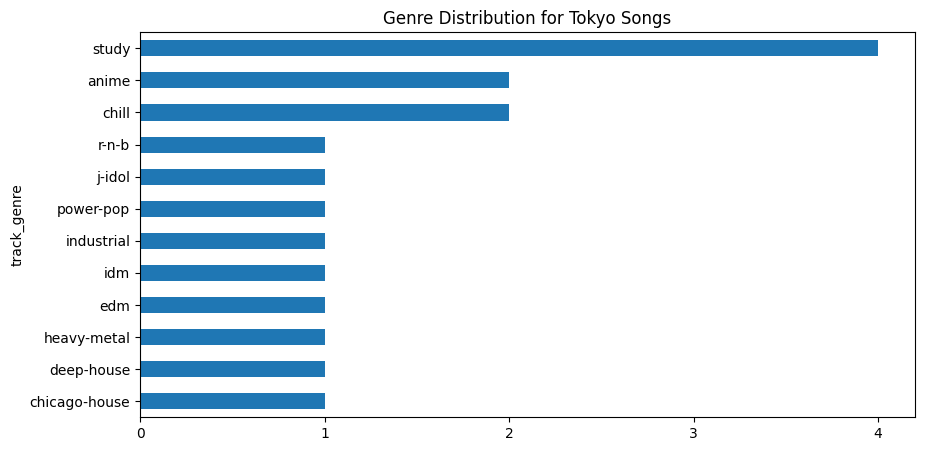

In [21]:
ax = matched_songs[matched_songs['matched_city'] == 'Tokyo'].groupby('track_genre').size().sort_values(ascending=True).plot(kind='barh', figsize=(10, 5), title='Genre Distribution for Tokyo Songs')
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.show()

In [22]:
matched_songs[matched_songs['matched_city'] == 'Tokyo'][['artists', 'album_name', 'track_name', 'track_genre', 'popularity']]

,artists,album_name,track_name,track_genre,popularity
5404,Hiroaki Tsutsumi,Tokyo Revengers Original Soundtrack,Tokyo Revengers -Main Theme-,anime,41
5591,Eve,Otogi,Tokyo Ghetto,anime,56
13245,Mark Farina,Live In Tokyo,Live In Tokyo - Continuous Mix,chicago-house,11
15326,Yusei,fell in love in tokyo,fell in love in tokyo,chill,43
15741,Yusei,Beyond Your Imagination,Romance in Tokyo,chill,13
23123,Ilkan Gunuc;Emrah Turken,My Name Is Tokyo,My Name Is Tokyo,deep-house,50
30954,Leat'eq,Tokyo,Tokyo,edm,61
50101,Beast In Black,Dark Connection,One Night in Tokyo,heavy-metal,62
54671,Cybass,Akane (Original Soundtrack),Big Trouble in Mega Tokyo,idm,10
58277,Area 11,All the Lights in the Sky,Tokyo House Party,industrial,28


In [23]:
matched_songs[(matched_songs['matched_city'] == 'Tokyo')].describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,17.000000,1.700000e+01,17.000000,17.000000,17.000000,17.000000,17.000000,17.000000,17.000000,17.000000,17.000000,17.000000,17.000000,17.000000
mean,34.117647,4.503441e+05,0.608882,0.706941,6.294118,-7.318235,0.647059,0.107735,0.299677,0.481301,0.159100,0.557176,117.613706,3.764706
std,21.192222,1.005048e+06,0.119706,0.232834,3.137768,3.948338,0.492592,0.108752,0.404873,0.401588,0.097734,0.223032,24.755785,0.752447
min,7.000000,8.572700e+04,0.381000,0.223000,1.000000,-16.991000,0.000000,0.032200,0.000013,0.000000,0.045000,0.202000,78.002000,1.000000
25%,13.000000,1.722160e+05,0.521000,0.546000,4.000000,-10.110000,0.000000,0.037000,0.008100,0.001410,0.081000,0.393000,99.982000,4.000000
50%,28.000000,1.870160e+05,0.642000,0.808000,6.000000,-6.090000,1.000000,0.055800,0.047400,0.691000,0.115000,0.562000,126.142000,4.000000
75%,50.000000,2.684930e+05,0.704000,0.879000,8.000000,-4.511000,1.000000,0.159000,0.778000,0.853000,0.234000,0.688000,131.981000,4.000000
max,71.000000,4.339826e+06,0.806000,0.977000,11.000000,-2.717000,1.000000,0.461000,0.974000,0.946000,0.328000,0.944000,159.276000,4.000000


# Bueno Aires

In [24]:
matched_songs[matched_songs['matched_city'] == 'Buenos Aires'].groupby('track_genre').size().sort_values(ascending=False)

track_genre
tango          7
guitar         1
hardcore       1
heavy-metal    1
punk-rock      1
show-tunes     1
dtype: int64

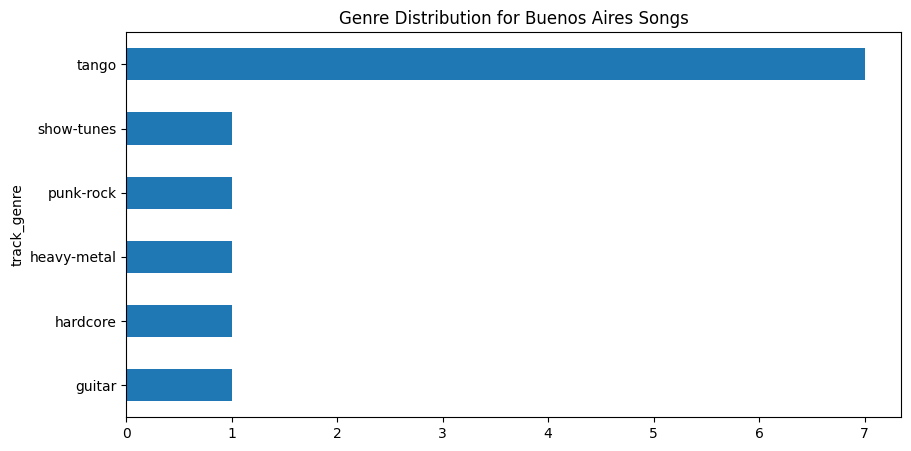

In [25]:
ax = matched_songs[matched_songs['matched_city'] == 'Buenos Aires'].groupby('track_genre').size().sort_values(ascending=True).plot(kind='barh', figsize=(10, 5), title='Genre Distribution for Buenos Aires Songs')
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.show()

Mi Buenos Aires Querido -> duplicate (tango should be reduced to 9)

In [26]:
matched_songs[matched_songs['matched_city'] == 'Buenos Aires']

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,matched_city
45163,0VYl6MeDfICsBCiopYfv0a,Las Lagrimas,Nostalgias De Buenos Aires,Nostalgias De Buenos Aires,28,197750,False,0.542,0.143,9,...,1,0.0617,0.976000,0.928000,0.1010,0.250,79.413,4,guitar,Buenos Aires
48581,0QTZidHShfs4zKlijYitPu,Dominic,Gemini (Deluxe Edition),Adiós Buenos Aires,31,205274,False,0.545,0.979,1,...,0,0.1140,0.046800,0.000000,0.3130,0.781,150.060,4,hardcore,Buenos Aires
50707,0kHXj7PnzoxdH9SHcj7Fzg,Lethal,Efecto Tequila,Estalla Buenos Aires,20,249613,False,0.309,0.966,1,...,1,0.1190,0.000142,0.005210,0.1560,0.311,123.545,3,heavy-metal,Buenos Aires
85595,3aMKVw1oXkAdeAVXO2TucF,Charly García,Pubis Angelical / Yendo De La Cama Al Living,No Bombardeen Buenos Aires,38,243680,False,0.757,0.662,7,...,1,0.0967,0.064300,0.014000,0.2930,0.851,99.792,4,punk-rock,Buenos Aires
98374,16R5kr4QDLscCha0IgP64v,Andrew Lloyd Webber;Elena Roger,Evita,Buenos Aires,27,239840,False,0.674,0.754,0,...,1,0.1580,0.315000,0.000024,0.4310,0.538,119.753,4,show-tunes,Buenos Aires
108019,4EdxXgcjlUv31rBSC1b5p7,Edmundo Rivero,Cafetín de Buenos Aires,Cafetín De Buenos Aires,31,203160,False,0.416,0.466,2,...,1,0.0826,0.979000,0.379000,0.1190,0.447,86.817,3,tango,Buenos Aires
108253,0FocbxQOKIMvvrtffXUzGz,Eladia Blazquez,Serie De Oro,La Voz De Buenos Aires,21,144200,False,0.467,0.327,5,...,0,0.0647,0.831000,0.000000,0.1690,0.355,106.897,4,tango,Buenos Aires
108338,71wzlKHB4nk5DyteVLvnDW,Carlos Gardel,Los Exitos De Sus Peliculas,Mi Buenos Aires Querido,22,162586,False,0.448,0.188,6,...,1,0.1150,0.983000,0.000000,0.1070,0.363,79.022,3,tango,Buenos Aires
108388,2dY4O7X5MS9VN4Dh51Tiy6,Roberto Goyeneche;Orquesta Tipica Porteña,15 Grandes Exitos - Los Discos De Oro De Rober...,El Cantor de Buenos Aires (with Orquesta Tipic...,21,165346,False,0.505,0.548,2,...,1,0.1230,0.719000,0.000000,0.2000,0.763,104.280,4,tango,Buenos Aires
108428,4t2Ow4sdp8p8OVfpu2e1Ey,Azucena Maizani;Nelly Omar;Orestes Cufaro,"Vintage Argentine Tangos (1928 - 1954), Vol. 2",La canción de Buenos Aires,20,165982,False,0.516,0.258,5,...,1,0.0545,0.679000,0.487000,0.1480,0.749,123.092,4,tango,Buenos Aires


In [27]:
matched_songs[matched_songs['matched_city'] == 'Buenos Aires'][['artists', 'album_name', 'track_name', 'track_genre', 'popularity']]

,artists,album_name,track_name,track_genre,popularity
45163,Las Lagrimas,Nostalgias De Buenos Aires,Nostalgias De Buenos Aires,guitar,28
48581,Dominic,Gemini (Deluxe Edition),Adiós Buenos Aires,hardcore,31
50707,Lethal,Efecto Tequila,Estalla Buenos Aires,heavy-metal,20
85595,Charly García,Pubis Angelical / Yendo De La Cama Al Living,No Bombardeen Buenos Aires,punk-rock,38
98374,Andrew Lloyd Webber;Elena Roger,Evita,Buenos Aires,show-tunes,27
108019,Edmundo Rivero,Cafetín de Buenos Aires,Cafetín De Buenos Aires,tango,31
108253,Eladia Blazquez,Serie De Oro,La Voz De Buenos Aires,tango,21
108338,Carlos Gardel,Los Exitos De Sus Peliculas,Mi Buenos Aires Querido,tango,22
108388,Roberto Goyeneche;Orquesta Tipica Porteña,15 Grandes Exitos - Los Discos De Oro De Rober...,El Cantor de Buenos Aires (with Orquesta Tipic...,tango,21
108428,Azucena Maizani;Nelly Omar;Orestes Cufaro,"Vintage Argentine Tangos (1928 - 1954), Vol. 2",La canción de Buenos Aires,tango,20


In [28]:
matched_songs[(matched_songs['matched_city'] == 'Buenos Aires')].describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000
mean,24.250000,194795.833333,0.515417,0.478417,3.583333,-9.591667,0.750000,0.090750,0.618187,0.160104,0.185183,0.526500,110.985833,3.750000
std,6.743684,38438.473125,0.136431,0.301729,2.968267,3.341241,0.452267,0.035606,0.396701,0.293301,0.106972,0.209239,22.763454,0.452267
min,16.000000,141906.000000,0.309000,0.143000,0.000000,-13.383000,0.000000,0.040400,0.000142,0.000000,0.087800,0.250000,79.022000,3.000000
25%,20.000000,164656.000000,0.440000,0.239500,1.000000,-13.106750,0.750000,0.061125,0.252325,0.000000,0.105500,0.361000,96.548250,3.750000
50%,21.500000,200455.000000,0.510500,0.396500,3.500000,-9.693000,1.000000,0.089650,0.775000,0.002617,0.152000,0.487000,112.004500,4.000000
75%,28.750000,223619.750000,0.577250,0.685000,5.250000,-7.424250,1.000000,0.116000,0.936250,0.175750,0.223250,0.752500,123.205250,4.000000
max,38.000000,249613.000000,0.757000,0.979000,9.000000,-2.926000,1.000000,0.158000,0.983000,0.928000,0.431000,0.851000,150.060000,4.000000


# Brooklyn

In [29]:
matched_songs[matched_songs['matched_city'] == 'Brooklyn'].groupby('track_genre').size().sort_values(ascending=False)

track_genre
study             2
alternative       1
garage            1
idm               1
minimal-techno    1
pop               1
dtype: int64

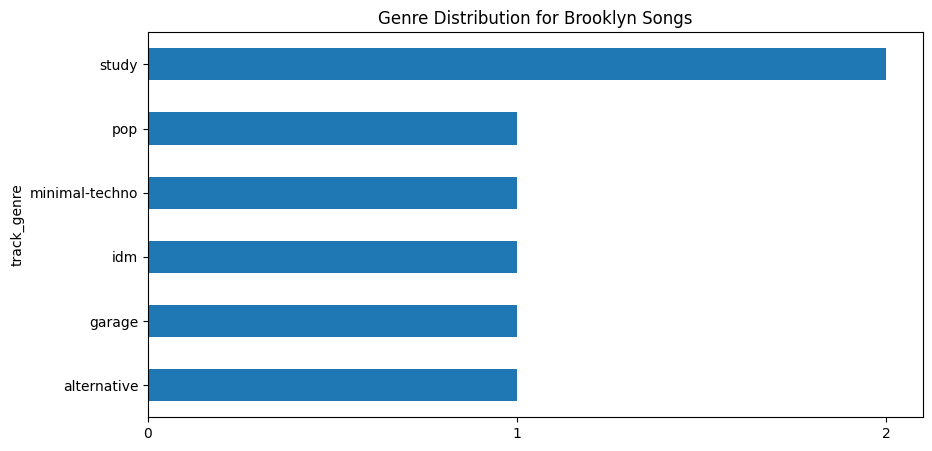

In [30]:
ax = matched_songs[matched_songs['matched_city'] == 'Brooklyn'].groupby('track_genre').size().sort_values(ascending=True).plot(kind='barh', figsize=(10, 5), title='Genre Distribution for Brooklyn Songs')
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.show()

In [31]:
matched_songs[matched_songs['matched_city'] == 'Brooklyn'][['artists', 'album_name', 'track_name', 'track_genre', 'popularity']]

,artists,album_name,track_name,track_genre,popularity
3628,Ol' Dirty Bastard,Rap Classics,Brooklyn Zoo,alternative,0
38131,The Strokes,The New Abnormal,Brooklyn Bridge To Chorus,garage,64
54243,Team Shadetek,Brooklyn Anthem,Brooklyn Anthem (feat. 77klash & Jahdan) - Voc...,idm,13
73894,Nicole Moudaber,Pure Intec 2 Mixed by Carl Cox & Jon Rundell,Brooklyn Hangover,minimal-techno,18
81694,Lana Del Rey,Frühstücksmusik Herbst/Winter 2022/2023,Brooklyn Baby,pop,0
105553,Smartface,Vivid Recollection,Brooklyn Cowboy,study,16
105886,"Sarah, the Illstrumentalist",Golden Skin,Beach Day in Brooklyn,study,24


In [32]:
matched_songs[(matched_songs['matched_city'] == 'Brooklyn')].describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.0
mean,19.285714,231615.714286,0.618143,0.650571,3.000000,-6.249286,0.571429,0.135971,0.280117,0.374723,0.239429,0.339857,107.724714,4.0
std,21.669597,70076.980390,0.164890,0.133726,4.281744,2.442982,0.534522,0.142403,0.253816,0.468176,0.271999,0.237895,22.080150,0.0
min,0.000000,138370.000000,0.378000,0.451000,0.000000,-10.673000,0.000000,0.040700,0.006020,0.000000,0.079700,0.087900,77.238000,4.0
25%,6.500000,195257.000000,0.519000,0.578000,0.500000,-7.150000,0.000000,0.049000,0.044900,0.000046,0.096650,0.110050,92.359500,4.0
50%,16.000000,215040.000000,0.628000,0.647000,1.000000,-5.824000,1.000000,0.062800,0.253000,0.003970,0.156000,0.381000,106.316000,4.0
75%,21.000000,262873.000000,0.749000,0.732500,4.000000,-4.776000,1.000000,0.179150,0.530000,0.832000,0.202000,0.515500,122.888500,4.0
max,64.000000,351640.000000,0.785000,0.835000,11.000000,-3.396000,1.000000,0.392000,0.552000,0.955000,0.843000,0.659000,140.023000,4.0


# Los Angeles

In [33]:
matched_songs[matched_songs['matched_city'] == 'Los Angeles'].groupby('track_genre').size().sort_values(ascending=False)

track_genre
chill         1
dancehall     1
electro       1
happy         1
hardstyle     1
industrial    1
dtype: int64

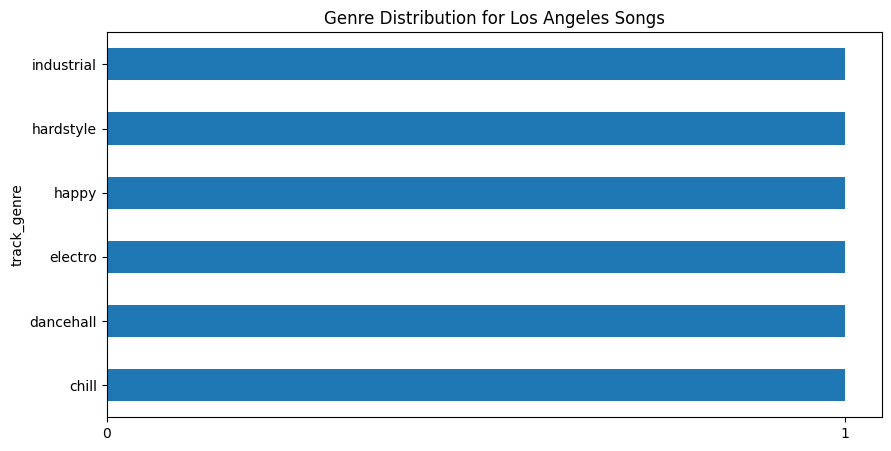

In [34]:
ax = matched_songs[matched_songs['matched_city'] == 'Los Angeles'].groupby('track_genre').size().sort_values(ascending=True).plot(kind='barh', figsize=(10, 5), title='Genre Distribution for Los Angeles Songs')
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.show()

K-pop needs to be removed since LA DI DA -> LA doesn't mean Los Angeles here

In [35]:
matched_songs[matched_songs['matched_city'] == 'Los Angeles']

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,matched_city
15504,391ld8zBXxJRJlspCe6kUR,ASTN,LA DON’T LOOK GOOD ON U,LA DON’T LOOK GOOD ON U,57,156340,False,0.870,0.387,1,...,0,0.0354,0.052200,0.000000,0.3210,0.628,100.038,4,chill,Los Angeles
21369,0X9MmC3La4fWsaceYFHwWK,Mwuana,LA Strip Joint,LA Strip Joint,36,182383,True,0.756,0.694,9,...,0,0.1470,0.266000,0.000000,0.0929,0.702,151.932,4,dancehall,Los Angeles
31724,0uLPKDuIhkIhttiwezNdiG,Alec Benjamin,These Two Windows,Jesus in LA,66,171539,False,0.787,0.558,0,...,1,0.0414,0.664000,0.000000,0.3470,0.706,94.049,4,electro,Los Angeles
46567,58D9k8iwhJOU81EHhHZSTi,S3RL;Lexi,LA 2015 (feat. Lexi),LA 2015 (feat. Lexi),19,179042,False,0.523,0.925,1,...,1,0.0573,0.000724,0.000012,0.3810,0.705,174.935,4,happy,Los Angeles
49373,7GQmHduf6lCVI1uBGrP25P,Gunz For Hire,This Is Los Angeles,This is Los Angeles - Radio Edit,23,260800,False,0.569,0.979,1,...,0,0.1280,0.023400,0.357000,0.1180,0.211,150.021,4,hardstyle,Los Angeles
58551,50zu0sYFPOwXaczd2gAht0,Marilyn Manson,The Pale Emperor,The Mephistopheles Of Los Angeles,44,297168,False,0.625,0.908,2,...,1,0.0896,0.000201,0.000305,0.0987,0.199,124.997,4,industrial,Los Angeles


In [36]:
matched_songs[(matched_songs['matched_city'] == 'Los Angeles')].describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.0
mean,40.833333,207878.666667,0.688333,0.741833,2.333333,-4.294167,0.500000,0.083117,0.167754,0.059553,0.226433,0.525167,132.662000,4.0
std,18.562507,56976.557403,0.136311,0.236389,3.326660,1.625645,0.547723,0.046522,0.263088,0.145719,0.136583,0.249788,31.855033,0.0
min,19.000000,156340.000000,0.523000,0.387000,0.000000,-6.490000,0.000000,0.035400,0.000201,0.000000,0.092900,0.199000,94.049000,4.0
25%,26.250000,173414.750000,0.583000,0.592000,1.000000,-5.143000,0.000000,0.045375,0.006393,0.000000,0.103525,0.315250,106.277750,4.0
50%,40.000000,180712.500000,0.690500,0.801000,1.000000,-4.470500,0.500000,0.073450,0.037800,0.000006,0.219500,0.665000,137.509000,4.0
75%,53.750000,241195.750000,0.779250,0.920750,1.750000,-3.472500,1.000000,0.118400,0.212550,0.000232,0.340500,0.704250,151.454250,4.0
max,66.000000,297168.000000,0.870000,0.979000,9.000000,-1.827000,1.000000,0.147000,0.664000,0.357000,0.381000,0.706000,174.935000,4.0


# Amsterdam

In [37]:
matched_songs[matched_songs['matched_city'] == 'Amsterdam'].groupby('track_genre').size().sort_values(ascending=False)

track_genre
deep-house    2
chill         1
folk          1
french        1
party         1
dtype: int64

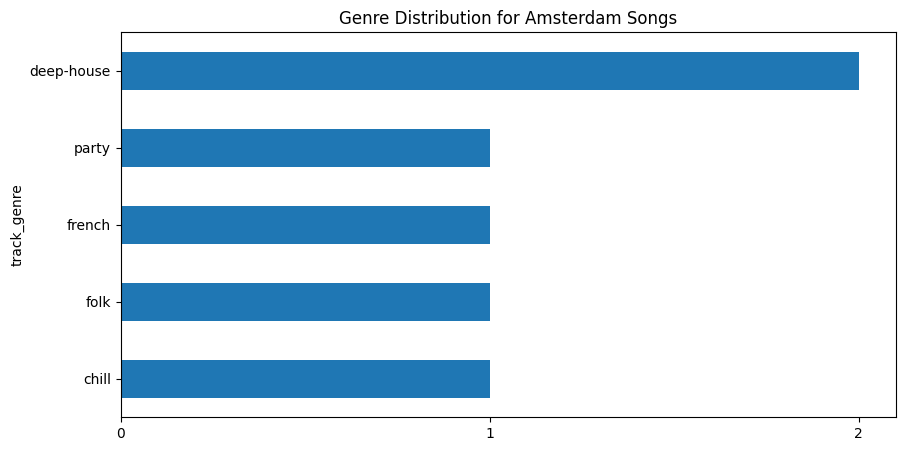

In [38]:
ax = matched_songs[matched_songs['matched_city'] == 'Amsterdam'].groupby('track_genre').size().sort_values(ascending=True).plot(kind='barh', figsize=(10, 5), title='Genre Distribution for Amsterdam Songs')
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.show()

In [39]:
matched_songs[matched_songs['matched_city'] == 'Amsterdam']

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,matched_city
15455,3LRbalLzZcuvSR6jVnqclh,RINI,After the Sun,Meet Me in Amsterdam,65,301448,False,0.620,0.265,9,...,0,0.0345,0.281000,0.000010,0.1140,0.169,106.022,3,chill,Amsterdam
23566,4cTo1wbzGiVJJiCG3BdZ64,MÖWE;Jonasu;Eskeemo,Lost In Amsterdam (feat. Eskeemo),Lost In Amsterdam (feat. Eskeemo),52,144813,False,0.781,0.675,7,...,1,0.0359,0.473000,0.000028,0.1480,0.755,116.971,4,deep-house,Amsterdam
23780,3U6ZWTjjYDtr2YMhG0fpsM,CALVO,Broke In Amsterdam,Broke In Amsterdam,52,175368,False,0.770,0.722,6,...,0,0.0327,0.070800,0.000000,0.1010,0.711,105.995,4,deep-house,Amsterdam
34775,7iQmjnDXYngWGsbjVnDc1U,Gregory Alan Isakov,The Weatherman,Amsterdam,67,198640,False,0.553,0.429,3,...,1,0.0283,0.921000,0.135000,0.1150,0.532,152.047,3,folk,Amsterdam
36693,6hWgYiiafHmpFFSTDnb1eD,Parabellum,Gratuit: 2 Morceaux en Moins,Ilot Amsterdam,32,182440,False,0.318,0.950,11,...,0,0.1040,0.000167,0.000007,0.0722,0.369,100.224,3,french,Amsterdam
78530,4ik7U3CHIZp8mDx7zV8ZeU,Paveier,Karneval der Stars 49,Sieben Nächte lang in Amsterdam,29,195386,False,0.653,0.766,0,...,1,0.0320,0.000576,0.000009,0.2530,0.785,129.937,4,party,Amsterdam


In [40]:
matched_songs[(matched_songs['matched_city'] == 'Amsterdam')].describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,6.000000,6.000000,6.000000,6.000000,6.00,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000
mean,49.500000,199682.500000,0.615833,0.634500,6.00,-7.477333,0.500000,0.044567,0.291090,0.022509,0.133867,0.553500,118.532667,3.500000
std,16.034338,53432.058646,0.170352,0.246937,4.00,3.454729,0.547723,0.029231,0.359873,0.055109,0.063287,0.245497,19.517302,0.547723
min,29.000000,144813.000000,0.318000,0.265000,0.00,-12.510000,0.000000,0.028300,0.000167,0.000000,0.072200,0.169000,100.224000,3.000000
25%,37.000000,177136.000000,0.569750,0.490500,3.75,-9.767250,0.000000,0.032175,0.018132,0.000007,0.104250,0.409750,106.001750,3.000000
50%,52.000000,188913.000000,0.636500,0.698500,6.50,-6.913500,0.500000,0.033600,0.175900,0.000009,0.114500,0.621500,111.496500,3.500000
75%,61.750000,197826.500000,0.740750,0.755000,8.50,-4.621500,1.000000,0.035550,0.425000,0.000023,0.139750,0.744000,126.695500,4.000000
max,67.000000,301448.000000,0.781000,0.950000,11.00,-3.951000,1.000000,0.104000,0.921000,0.135000,0.253000,0.785000,152.047000,4.000000


# Plot radar graph for avarage audio features of top 5 cities

In [41]:
features = ['danceability', 'energy', 'valence', 'tempo',
            'acousticness', 'instrumentalness', 'speechiness',
            'liveness', 'loudness']

city_features = matched_songs.groupby('matched_city')[features].mean()

top_genre = (matched_songs.groupby('matched_city')['track_genre']
                          .agg(lambda x: x.value_counts().index[0])
                          .rename('top_genre'))

song_count = (matched_songs.groupby('matched_city')['track_name']
                           .count()
                           .rename('song_count'))

city_df = pd.concat([city_features, top_genre, song_count], axis=1).reset_index()

print(city_df.shape)
print(city_df.head())

(84, 12)
  matched_city  danceability    energy   valence       tempo  acousticness  \
0       Adachi      0.833000  0.432000  0.237000  108.676000      0.257000   
1       Agadir      0.475000  0.961000  0.359000   97.204000      0.000031   
2    Amsterdam      0.615833  0.634500  0.553500  118.532667      0.291090   
3       Ankara      0.444000  0.615333  0.328333   76.493000      0.606667   
4      Baghdad      0.724000  0.509000  0.341000  134.026000      0.010400   

   instrumentalness  speechiness  liveness   loudness       top_genre  \
0          0.890000     0.043800  0.137000 -11.625000           study   
1          0.002290     0.109000  0.144000  -3.839000     heavy-metal   
2          0.022509     0.044567  0.133867  -7.477333      deep-house   
3          0.148077     0.021600  0.393233 -14.205000          j-rock   
4          0.860000     0.048900  0.128000 -13.020000  detroit-techno   

   song_count  
0           1  
1           1  
2           6  
3           3  
4  

In [42]:
city_df = city_df[city_df['song_count'] > 4].reset_index(drop=True) # Keep cities with at least 5 songs

In [43]:
print(city_df.sort_values('song_count', ascending=False))

   matched_city  danceability    energy   valence       tempo  acousticness  \
4        London      0.591480  0.600040  0.482868  129.649480      0.338399   
6         Tokyo      0.608882  0.706941  0.557176  117.613706      0.299677   
2  Buenos Aires      0.515417  0.478417  0.526500  110.985833      0.618187   
1      Brooklyn      0.618143  0.650571  0.339857  107.724714      0.280117   
0     Amsterdam      0.615833  0.634500  0.553500  118.532667      0.291090   
5   Los Angeles      0.688333  0.741833  0.525167  132.662000      0.167754   
3       Chicago      0.719400  0.722600  0.268540  124.849800      0.108514   

   instrumentalness  speechiness  liveness  loudness      top_genre  \
4          0.267465     0.084240  0.194564 -9.985960        british   
6          0.481301     0.107735  0.159100 -7.318235          study   
2          0.160104     0.090750  0.185183 -9.591667          tango   
1          0.374723     0.135971  0.239429 -6.249286          study   
0          0

In [44]:
radar_features = ['danceability', 'energy', 'valence',
                  'acousticness', 'instrumentalness']

top5_cities = (matched_songs
               .groupby('matched_city')
               .size()
               .sort_values(ascending=False)
               .head(5)
               .index.tolist())

print(f"Top 5 cities: {top5_cities}")

top5_profiles = (matched_songs[matched_songs['matched_city'].isin(top5_cities)]
                 .groupby('matched_city')[radar_features]
                 .mean()
                 .round(3))

angles = np.linspace(0, 2 * np.pi, len(radar_features), endpoint=False).tolist()
angles += angles[:1]  # close the circle

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

Top 5 cities: ['London', 'Tokyo', 'Buenos Aires', 'Brooklyn', 'Amsterdam']


## Plot radar graph per city

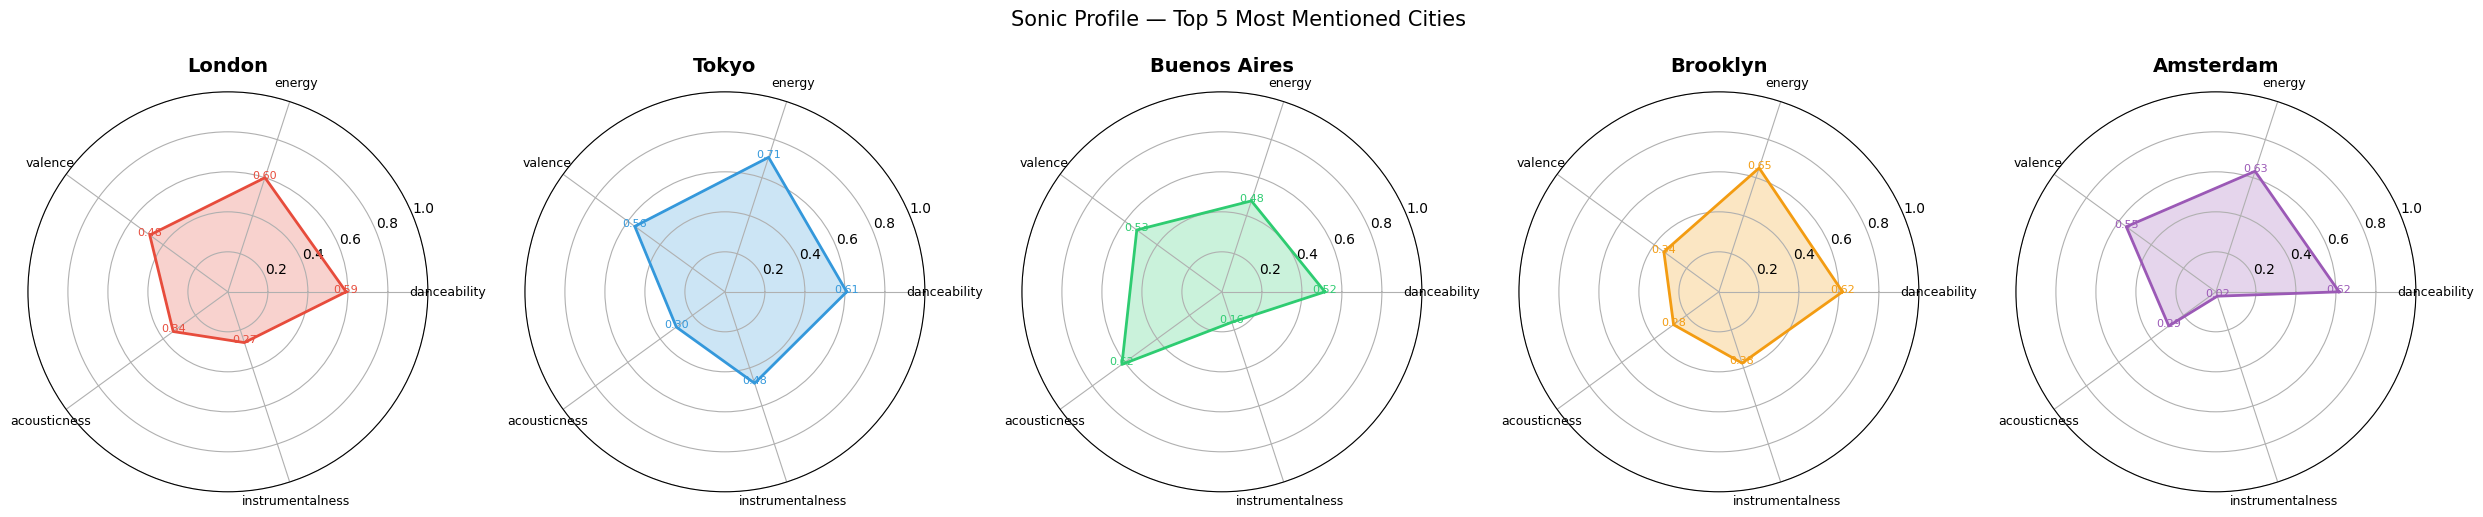

In [45]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5), subplot_kw=dict(polar=True))  # ← wider

for ax, city, color in zip(axes, top5_cities, colors):
    values = top5_profiles.loc[city, radar_features].tolist()
    values += values[:1]

    ax.plot(angles, values, color=color, linewidth=2)
    ax.fill(angles, values, color=color, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_features, size=9)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_title(city, size=14, pad=15, fontweight='bold')

    for angle, value in zip(angles[:-1], values[:-1]):
        ax.annotate(f'{value:.2f}', xy=(angle, value), fontsize=8,
                    ha='center', color=color)

plt.suptitle('Sonic Profile — Top 5 Most Mentioned Cities', size=15, y=1.02)
plt.tight_layout()
plt.show()

In [46]:
import os

output_dir = "pic"
os.makedirs(output_dir, exist_ok=True)

for city, color in zip(top5_cities, colors):
    values = top5_profiles.loc[city, radar_features].tolist()
    values += values[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

    ax.plot(angles, values, color=color, linewidth=2)
    ax.fill(angles, values, color=color, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_features, size=9)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_title(city, size=14, pad=15, fontweight='bold')

    for angle, value in zip(angles[:-1], values[:-1]):
        ax.annotate(f'{value:.2f}', xy=(angle, value), fontsize=8,
                    ha='center', color=color)

    plt.tight_layout()
    filename = os.path.join(output_dir, f"radar_{city.replace(' ', '_')}.png")
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Saved: {filename}")

print("All radar charts saved!")

Saved: pic\radar_London.png
Saved: pic\radar_Tokyo.png
Saved: pic\radar_Buenos_Aires.png
Saved: pic\radar_Brooklyn.png
Saved: pic\radar_Amsterdam.png
All radar charts saved!


## Overlay 5 cities in one graph

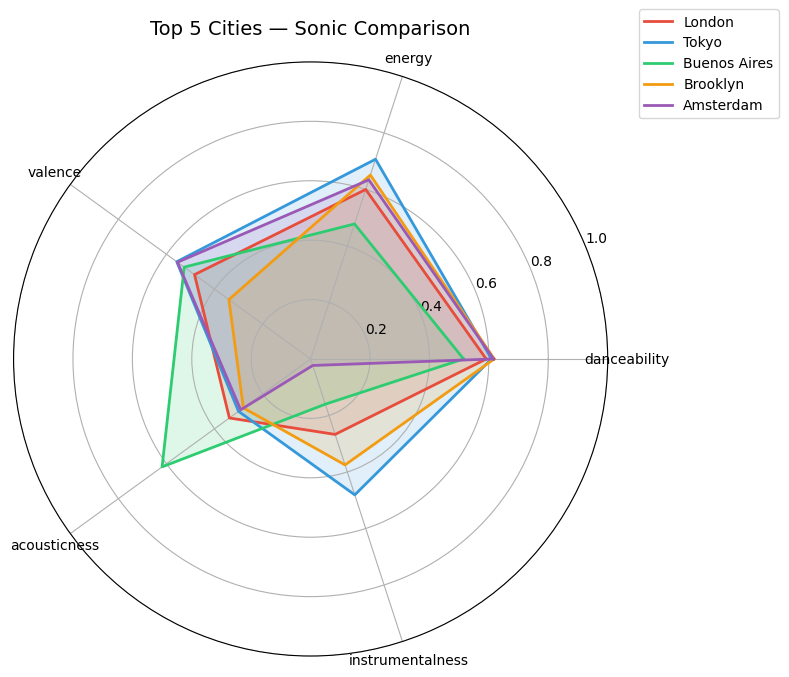

In [47]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for city, color in zip(top5_cities, colors):
    values = top5_profiles.loc[city, radar_features].tolist()
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2, label=city)
    ax.fill(angles, values, color=color, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_features, size=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.set_title('Top 5 Cities — Sonic Comparison', size=14, pad=20)

plt.tight_layout()
plt.show()